# Section 4.1.5 — Near-optimality of the LLL-based search

Theorem 3.4 proves the *existence* of a good Korobov parameter; Algorithm 3.2 selects one with an LLL surrogate. Here we compute the **exact** shortest primal/dual vectors (by enumerating the defining congruence) for every candidate $a$ in low dimensions, and confirm that the LLL-selected $a^*$ is essentially optimal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lattice_qmc import KorobovLattice, ExplicitRank1Lattice
from lattice_qmc.utils import compute_separation_radius_fast
from lattice_qmc.baselines import maximin_lhd, matern52_gram

try:
    import qmcpy as qp
    QMCPY_AVAILABLE = True
except ImportError:
    QMCPY_AVAILABLE = False

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif', 'axes.labelsize': 14,
    'legend.fontsize': 10, 'figure.figsize': (7, 5), 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'lines.linewidth': 2, 'lines.markersize': 8,
})

# Load optimal Korobov parameters
korobov_params = np.load('data/korobov_optimal_parameters.npy', allow_pickle=True).item()
korobov_primes = korobov_params['primes']
optimal_generators = korobov_params['optimal_generators']

STYLES = {
    'korobov':  {'color': '#1f77b4', 'marker': 'o', 'label': 'Korobov (ours)'},
    'explicit': {'color': '#d62728', 'marker': 's', 'label': 'Explicit (ours)'},
    'lhd':      {'color': '#ff7f0e', 'marker': 'P', 'label': 'Maximin LHD'},
    'random':   {'color': '#7f7f7f', 'marker': 'x', 'label': 'Random'},
    'halton':   {'color': '#2ca02c', 'marker': '^', 'label': 'Halton'},
    'sobol':    {'color': '#9467bd', 'marker': 'D', 'label': "Sobol'"},
}
print('Setup complete.')


Setup complete.


In [2]:
from itertools import product as iproduct

def centered_residue(x, N):
    r = np.mod(x, N)
    return np.where(r > N // 2, r - N, r)

def exact_dual_lambda1(a, N, d):
    powers = np.array([pow(a, j, N) for j in range(d)], dtype=np.int64)
    B = int(np.ceil(np.sqrt(d) * N ** (1.0 / d))) + 1
    rng = np.arange(-B, B + 1)
    best = float(N)
    grids = np.meshgrid(*([rng] * (d - 1)), indexing='ij')
    H = np.stack([g.ravel() for g in grids], axis=1)
    s = (H * powers[1:]).sum(axis=1)
    h0 = centered_residue(-s, N)
    norm2 = h0 ** 2 + (H ** 2).sum(axis=1)
    zero = (h0 == 0) & np.all(H == 0, axis=1)
    norm2 = np.where(zero, np.iinfo(np.int64).max, norm2)
    return float(min(best, np.sqrt(norm2.min())))

def exact_primal_lambda1(a, N, d):
    powers = np.array([pow(a, j, N) for j in range(d)], dtype=np.int64)
    C = min(N - 1, int(np.ceil(np.sqrt(d) * N ** ((d - 1.0) / d))) + 1)
    c0 = np.arange(1, C + 1)
    total = c0.astype(np.float64) ** 2
    for j in range(1, d):
        total = total + centered_residue(powers[j] * c0, N).astype(np.float64) ** 2
    return np.sqrt(min(float(N * N), float(total.min()))) / N


In [3]:
PRIMES = [13, 31, 61, 127, 251, 509, 1021]
DIMS = [2, 3, 5]
rows, scatter = [], None
for d in DIMS:
    for N in PRIMES:
        if d == 5 and N > 509:
            continue
        ex_d, ex_p, ll_d, ll_p = [], [], [], []
        for a in range(1, N):
            ex_d.append(exact_dual_lambda1(a, N, d)); ex_p.append(exact_primal_lambda1(a, N, d))
            lat = KorobovLattice(d=d, N=N, generator=a)
            ll_d.append(lat.lambda1_dual); ll_p.append(lat.lambda1_primal)
        ex_d, ex_p = np.array(ex_d), np.array(ex_p)
        ll_d, ll_p = np.array(ll_d), np.array(ll_p)
        exact_score, lll_score = ex_p * ex_d, ll_p * ll_d
        a_lll = int(np.argmax(lll_score)) + 1; a_ex = int(np.argmax(exact_score)) + 1
        eff = exact_score[a_lll - 1] / exact_score[a_ex - 1]
        rows.append(dict(d=d, N=N, efficiency=eff))
        print(f"d={d} N={N:5d}: a_LLL={a_lll:5d} a_exact={a_ex:5d} efficiency={eff:.4f}")
        if d == 3 and N == 251:
            scatter = (ex_d.copy(), ll_d.copy(), d, N)


d=2 N=   13: a_LLL=    8 a_exact=    5 efficiency=1.0000
d=2 N=   31: a_LLL=   12 a_exact=   12 efficiency=1.0000
d=2 N=   61: a_LLL=   53 a_exact=    8 efficiency=1.0000
d=2 N=  127: a_LLL=  115 a_exact=   12 efficiency=1.0000
d=2 N=  251: a_LLL=  177 a_exact=   74 efficiency=1.0000


d=2 N=  509: a_LLL=  376 a_exact=  133 efficiency=1.0000


d=2 N= 1021: a_LLL=  798 a_exact=   96 efficiency=1.0000
d=3 N=   13: a_LLL=    2 a_exact=    2 efficiency=1.0000
d=3 N=   31: a_LLL=   17 a_exact=   11 efficiency=1.0000
d=3 N=   61: a_LLL=   15 a_exact=    4 efficiency=1.0000
d=3 N=  127: a_LLL=  102 a_exact=   25 efficiency=1.0000


d=3 N=  251: a_LLL=  106 a_exact=   45 efficiency=1.0000


d=3 N=  509: a_LLL=  225 a_exact=   64 efficiency=0.9571


...

d=5 N=   31: a_LLL=    2 a_exact=    2 efficiency=1.0000


d=5 N=   61: a_LLL=   49 a_exact=    5 efficiency=1.0000


d=5 N=  127: a_LLL=   82 a_exact=   45 efficiency=1.0000


d=5 N=  251: a_LLL=  124 a_exact=   83 efficiency=1.0000


d=5 N=  509: a_LLL=   20 a_exact=   20 efficiency=1.0000


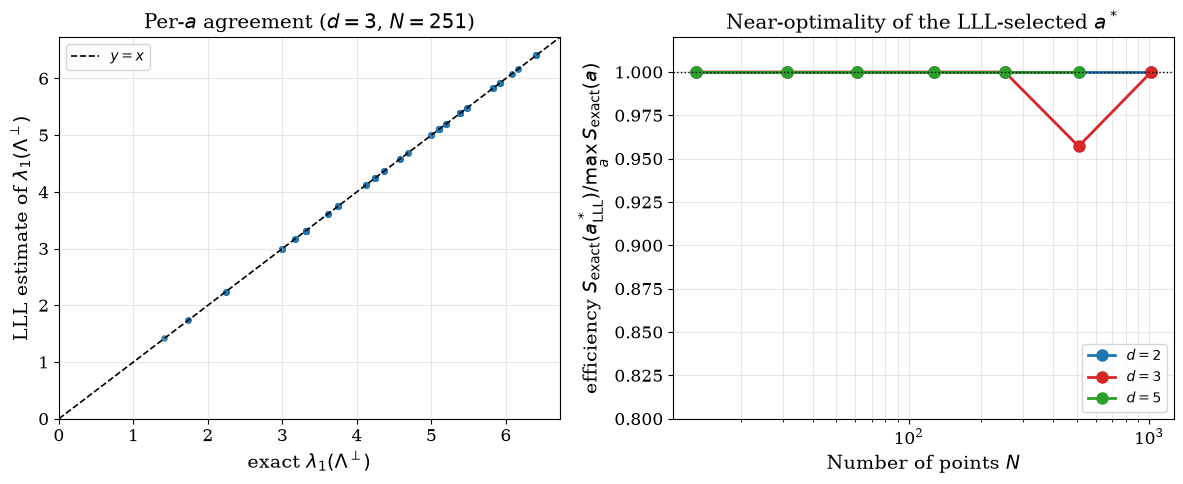

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ex_d, ll_d, d0, N0 = scatter
ax = axes[0]
ax.scatter(ex_d, ll_d, s=14, alpha=0.5, color='#1f77b4')
lim = [0, max(ex_d.max(), ll_d.max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=1.2, label='$y=x$')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(r'exact $\lambda_1(\Lambda^\perp)$')
ax.set_ylabel(r'LLL estimate of $\lambda_1(\Lambda^\perp)$')
ax.set_title(f'Per-$a$ agreement ($d={d0}$, $N={N0}$)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
ax = axes[1]
colors = {2: '#1f77b4', 3: '#d62728', 5: '#2ca02c'}
for d in DIMS:
    Ns = [r['N'] for r in rows if r['d'] == d]
    eff = [r['efficiency'] for r in rows if r['d'] == d]
    ax.plot(Ns, eff, marker='o', color=colors[d], label=f'$d={d}$')
ax.axhline(1.0, color='k', ls=':', lw=1); ax.set_xscale('log'); ax.set_ylim(0.8, 1.02)
ax.set_xlabel('Number of points $N$')
ax.set_ylabel(r'efficiency $S_{\rm exact}(a^*_{\rm LLL})/\max_a S_{\rm exact}(a)$')
ax.set_title('Near-optimality of the LLL-selected $a^*$')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout(); fig.savefig('LLL_optimality.png', dpi=300); plt.show()
